# [Cell 0] Step 5: Final Sticker Productization — Optional Textual Generate

**STAT 6209 Topic 3 — Sticker Design Generation**

This notebook takes generated sticker images from upstream LoRA pipelines (flat, cartoon, watercolor),
overlays short text captions, and outputs production-ready final sticker images.

**Pipeline**: `sticker_results/<style>/` → load captions → overlay text → `output_final/<style>/`

## [Cell 1] 1. Configuration & Imports

In [ ]:
%pip install Pillow -q

import os
import json
import re
from pathlib import Path
from collections import Counter
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageStat
from IPython.display import display, HTML

# ====================== Path Configuration ======================
# Auto-detect project root (works regardless of notebook CWD)
_cwd = Path(".").resolve()
_candidates = [_cwd, _cwd / "stat-6209-topic-3-project", _cwd.parent, _cwd.parent.parent]
PROJECT_ROOT = _cwd  # default fallback
for _c in _candidates:
    if (_c / "sticker_results").exists():
        PROJECT_ROOT = _c
        break

STEP5_DIR = PROJECT_ROOT / "step5-textual-generate"
INPUT_DIR = PROJECT_ROOT / "sticker_results"
OUTPUT_DIR = STEP5_DIR / "output_final"
CAPTIONS_FILE = STEP5_DIR / "text_captions_vlm.json"  # VLM-generated captions

# Style -> input directory mapping (prefer 4.19 new version, fallback to original)
STYLE_INPUT_MAP = {
    "flat":       [INPUT_DIR / "flat 4.19",       INPUT_DIR / "flat"],
    "cartoon":    [INPUT_DIR / "cartoon 4.19",    INPUT_DIR / "cartoon"],
    "watercolor": [INPUT_DIR / "watercolor 4.19", INPUT_DIR / "watercolor"],
}

# Supported image formats
SUPPORTED_EXTS = {".png", ".jpg", ".jpeg", ".webp"}

# ====================== Output Settings ======================
OUTPUT_SIZE = (512, 512)
OUTPUT_FORMAT = "PNG"

# Ensure output directories exist
for style in STYLE_INPUT_MAP:
    (OUTPUT_DIR / style).mkdir(parents=True, exist_ok=True)

print("=== Configuration ===")
print(f"  Project root:     {PROJECT_ROOT}")
print(f"  Output directory: {OUTPUT_DIR.resolve()}")
print(f"  Captions file:    {CAPTIONS_FILE.resolve()}")
print(f"  Output size:      {OUTPUT_SIZE}")
print()
for style, dirs in STYLE_INPUT_MAP.items():
    for d in dirs:
        if d.exists():
            n = len([f for f in d.iterdir() if f.suffix.lower() in SUPPORTED_EXTS])
            if n > 0:
                print(f"  [{style:12s}] {n:3d} images in {d.name}")
                break
    else:
        print(f"  [{style:12s}]   0 images (no source found)")
print("\nConfiguration loaded.")

=== Configuration ===
  Project root:     C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project
  Output directory: C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\step5-textual-generate\output_final
  Captions file:    C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\step5-textual-generate\text_captions.json
  Output size:      (512, 512)

  [flat        ]  37 images in C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\sticker_results\flat
  [cartoon     ]  37 images in C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\sticker_results\cartoon
  [watercolor  ]  37 images in C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\sticker_results\watercolor

Configuration loaded.


## [Cell 3] 2. Load Captions

In [2]:
def load_captions(captions_file: Path) -> dict:
    """Load caption mapping from JSON. Returns dict: filename -> caption."""
    if not captions_file.exists():
        print(f"Warning: {captions_file} not found. Will use auto-generated captions.")
        return {}

    with open(captions_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    caption_map = {}
    for item in data:
        fname = item.get("file_name", "")
        caption = item.get("caption", "")
        if fname and caption:
            caption_map[fname] = caption
            caption_map[Path(fname).stem] = caption

    print(f"Loaded {len(data)} captions from {captions_file.name}")
    return caption_map


# Load captions
caption_map = load_captions(CAPTIONS_FILE)

# Preview first entries
for i, (k, v) in enumerate(caption_map.items()):
    if i >= 10:
        break
    print(f"  {k:25s} -> {v}")
print("  ...")

Loaded 37 captions from text_captions.json
  animal_1.png              -> Cool Cat
  animal_1                  -> Cool Cat
  animal_2.png              -> Cute Cats
  animal_2                  -> Cute Cats
  animal_3.png              -> Twin Cats
  animal_3                  -> Twin Cats
  animal_4.png              -> Big Bear
  animal_4                  -> Big Bear
  animal_5.png              -> Happy Penguin
  animal_5                  -> Happy Penguin
  ...


## [Cell 5] 3. Default Caption Generator

In [3]:
# Common animal keywords for fallback caption generation
ANIMAL_KEYWORDS = [
    "cat", "dog", "rabbit", "bunny", "bear", "fox", "panda", "lion",
    "tiger", "elephant", "giraffe", "monkey", "bird", "fish", "deer",
    "penguin", "cow", "turtle", "llama", "kangaroo", "capybara", "wolf",
    "koala", "owl", "hamster", "puppy", "kitten",
]

CUTE_PREFIXES = ["Cute", "Happy", "Little", "Sweet", "Lovely"]

# Style prefixes used in generated filenames (e.g. flat_animal_1.png)
STYLE_PREFIXES = ["flat_", "cartoon_", "watercolor_"]


def strip_style_prefix(name: str) -> str:
    """Remove style prefix from filename, e.g. 'flat_animal_1' -> 'animal_1'."""
    for prefix in STYLE_PREFIXES:
        if name.startswith(prefix):
            return name[len(prefix):]
    return name


def generate_default_caption(filename: str) -> str:
    """Generate a short cute caption from the filename.
    Extracts animal name if possible, prepends a cute adjective."""
    stem = Path(filename).stem.lower()
    cleaned = re.sub(r"[_\-]", " ", stem)
    cleaned = re.sub(r"\d+", "", cleaned).strip()

    for animal in ANIMAL_KEYWORDS:
        if animal in cleaned:
            import random
            prefix = random.choice(CUTE_PREFIXES)
            return f"{prefix} {animal.capitalize()}"

    return "Cute Sticker"


def get_caption(filename: str, caption_map: dict) -> str:
    """Get caption: lookup in map first (with style-prefix stripping), then auto-generate."""
    stem = Path(filename).stem
    # Direct lookup
    if filename in caption_map:
        return caption_map[filename]
    if stem in caption_map:
        return caption_map[stem]
    # Try stripping style prefix (flat_animal_1 -> animal_1)
    base_name = strip_style_prefix(filename)
    base_stem = strip_style_prefix(stem)
    if base_name in caption_map:
        return caption_map[base_name]
    if base_stem in caption_map:
        return caption_map[base_stem]
    return generate_default_caption(filename)


# Quick test
test_files = ["flat_animal_1.png", "cartoon_animal_5.png", "watercolor_animal_10.png", "unknown_image.jpg"]
for tf in test_files:
    cap = get_caption(tf, caption_map)
    print(f'  {tf:35s} -> "{cap}"')

  flat_animal_1.png                   -> "Cool Cat"
  cartoon_animal_5.png                -> "Happy Penguin"
  watercolor_animal_10.png            -> "Little Deer"
  unknown_image.jpg                   -> "Cute Sticker"


## [Cell 7] 3b. VLM Smart Caption Generation (Optional)

Instead of manually writing captions or using filename-based rules, we can use a **Vision-Language Model (VLM)** to look at each sticker image and generate a short, cute caption automatically.

This reuses the same POE API (GPT-4o-mini) that the upstream prompt generation module uses.

**To enable**: set `USE_VLM = True` and fill in your `POE_API_KEY` below.

In [4]:
import base64
import requests
import time

# ====================== VLM Configuration ======================
USE_VLM = False  # Set to True and provide API key to enable VLM caption generation
# --- POE API (requires active subscription) ---
POE_API_KEY = "YOUR_POE_API_KEY_HERE"  # Replace at runtime; do NOT commit real keys
POE_CHAT_COMPLETIONS_URL = "https://api.poe.com/v1/chat/completions"
VLM_MODEL = "gpt-4o-mini"

# Caption generation prompt
VLM_SYSTEM_PROMPT = (
    "You are a sticker caption writer. "
    "Given a sticker image, output ONLY a short cute caption (1 to 3 English words). "
    "Style: cute, fun, pet-friendly. "
    "Examples: Cool Cat, Happy Panda, Big Bear, Little Fox, Meow!, Hop Hop. "
    "Output ONLY the caption, nothing else."
)

# Cache to avoid redundant API calls
vlm_caption_cache = {}


def encode_image_to_base64(image_path: str) -> str:
    """Encode an image file to base64 string."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def generate_caption_vlm(image_path: str) -> str:
    """Use VLM (GPT-4o-mini via POE API) to generate a caption by looking at the image."""
    str_path = str(image_path)

    # Check cache first
    if str_path in vlm_caption_cache:
        return vlm_caption_cache[str_path]

    try:
        b64_image = encode_image_to_base64(str_path)
        ext = Path(str_path).suffix.lower().replace(".", "")
        if ext == "jpg":
            ext = "jpeg"
        mime_type = f"image/{ext}"

        headers = {
            "Authorization": f"Bearer {POE_API_KEY}",
            "Content-Type": "application/json",
        }

        payload = {
            "model": VLM_MODEL,
            "messages": [
                {"role": "system", "content": VLM_SYSTEM_PROMPT},
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:{mime_type};base64,{b64_image}"
                            },
                        },
                        {
                            "type": "text",
                            "text": "What is a good short cute caption for this sticker?",
                        },
                    ],
                },
            ],
            "max_tokens": 20,
            "temperature": 0.7,
        }

        print(f"    Calling POE API for {Path(str_path).name}...")
        response = requests.post(
            POE_CHAT_COMPLETIONS_URL, headers=headers, json=payload, timeout=60
        )
        print(f"    Response status: {response.status_code}")

        if response.status_code != 200:
            print(f"    Error: {response.text[:300]}")
            return None

        data = response.json()
        caption = data["choices"][0]["message"]["content"].strip().strip('"').strip("'")

        # Limit to 3 words max
        words = caption.split()
        if len(words) > 3:
            caption = " ".join(words[:3])

        vlm_caption_cache[str_path] = caption
        return caption

    except Exception as e:
        print(f"    VLM error for {Path(str_path).name}: {type(e).__name__}: {e}")
        return None


# Override get_caption to support VLM mode
_original_get_caption = get_caption

def get_caption(filename: str, caption_map: dict, image_path: str = None) -> str:
    """Get caption with VLM support.
    Priority: 1) JSON lookup (with style-prefix stripping)  2) VLM generation  3) filename-based fallback
    """
    stem = Path(filename).stem
    # Direct lookup
    if filename in caption_map:
        return caption_map[filename]
    if stem in caption_map:
        return caption_map[stem]
    # Try stripping style prefix (flat_animal_1 -> animal_1)
    base_name = strip_style_prefix(filename)
    base_stem = strip_style_prefix(stem)
    if base_name in caption_map:
        return caption_map[base_name]
    if base_stem in caption_map:
        return caption_map[base_stem]

    if USE_VLM and image_path is not None:
        vlm_result = generate_caption_vlm(image_path)
        if vlm_result:
            return vlm_result

    return generate_default_caption(filename)


# ====================== Quick Test ======================
if USE_VLM and POE_API_KEY != "YOUR_POE_API_KEY_HERE":
    print("VLM caption generation: ENABLED")
    print(f"  Model: {VLM_MODEL} (POE API)")
    print(f"  Testing with first available image...")

    test_image = None
    for style, dirs in STYLE_INPUT_MAP.items():
        for d in dirs:
            if d.exists():
                imgs = [f for f in d.iterdir() if f.suffix.lower() in SUPPORTED_EXTS]
                if imgs:
                    test_image = imgs[0]
                    break
        if test_image:
            break

    if test_image:
        print(f"  Found test image: {test_image.name}")
        result = generate_caption_vlm(str(test_image))
        if result:
            print(f'  VLM says: "{result}"')
        else:
            print("  VLM returned no result (see error above).")
    else:
        print("  No test image found.")
else:
    print("VLM caption generation: DISABLED")
    print("  To enable: set USE_VLM=True and provide a POE API key (requires subscription).")
    print("  Currently using: JSON lookup -> filename-based fallback")

VLM caption generation: DISABLED
  To enable: set USE_VLM=True and provide a POE API key (requires subscription).
  Currently using: JSON lookup -> filename-based fallback


In [5]:
# ====================== VLM Full Batch: Generate captions for ALL images ======================
# This bypasses JSON lookup and forces VLM to look at every image.
# Then we compare: Manual (JSON) captions vs VLM-generated captions.

if USE_VLM and POE_API_KEY != "YOUR_POE_API_KEY_HERE":
    print(f"Running VLM on ALL images (bypassing JSON)...\n")

    # Collect all images
    all_images = []
    for style, dirs in STYLE_INPUT_MAP.items():
        for d in dirs:
            if d.exists():
                imgs = [f for f in sorted(d.iterdir()) if f.suffix.lower() in SUPPORTED_EXTS]
                if imgs:
                    all_images.extend([(f, style) for f in imgs])
                    break

    vlm_results = {}
    for img_path, style in all_images:
        caption = generate_caption_vlm(str(img_path))
        vlm_results[img_path.name] = caption or "(failed)"
        time.sleep(0.3)  # Small delay to be polite to the API

    # Compare JSON vs VLM
    print("\n" + "=" * 80)
    print(f"{'Filename':<30s} | {'JSON Caption':<18s} | {'VLM Caption':<18s}")
    print("-" * 80)
    for fname, vlm_cap in vlm_results.items():
        base_stem = strip_style_prefix(Path(fname).stem)
        json_cap = caption_map.get(fname, caption_map.get(base_stem, "(none)"))
        marker = " *" if json_cap != vlm_cap else ""
        print(f"  {fname:<28s} | {json_cap:<18s} | {vlm_cap:<18s}{marker}")

    print("-" * 80)
    differ = sum(1 for f, v in vlm_results.items()
                 if caption_map.get(strip_style_prefix(Path(f).stem), "") != v)
    print(f"  {len(vlm_results)} images processed, {differ} captions differ from JSON (* marked)")
    print(f"  VLM cache size: {len(vlm_caption_cache)}")
else:
    print("Skipped: VLM not enabled or no API key.")

Skipped: VLM not enabled or no API key.


## [Cell 10] 4. Text Overlay Function

In [ ]:
# ====================== Style-Aware Text Overlay ======================
# Each style uses different font, color scheme, and rendering technique.
# Colors are extracted from the image; contrast is checked against local background.

def get_font(font_name, size):
    """Try to load a TrueType font by name, fallback to default."""
    candidates = [font_name] if font_name else []
    candidates += [
        "arialbd.ttf", "arial.ttf",
        "C:/Windows/Fonts/arialbd.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    ]
    for name in candidates:
        try:
            return ImageFont.truetype(name, size)
        except (OSError, IOError):
            continue
    return ImageFont.load_default()


def get_dominant_color(img):
    """Extract the most prominent saturated color from the image."""
    small = img.copy().resize((50, 50))
    pixels = list(small.convert("RGB").getdata())
    filtered = []
    for r, g, b in pixels:
        brightness = (r + g + b) / 3
        saturation = max(r, g, b) - min(r, g, b)
        if brightness < 40 or brightness > 220:
            continue
        if saturation < 20:
            continue
        filtered.append((r // 32 * 32, g // 32 * 32, b // 32 * 32))
    if not filtered:
        return (100, 150, 200)
    counter = Counter(filtered)
    dominant = counter.most_common(1)[0][0]
    r, g, b = dominant
    return (min(r + 30, 255), min(g + 30, 255), min(b + 30, 255))


def get_local_bg_brightness(img, x, y, tw, th):
    """Sample average brightness of the image in the text area."""
    w, h = img.size
    left = max(0, x - 10)
    top = max(0, y - 5)
    right = min(w, x + tw + 10)
    bottom = min(h, y + th + 5)
    region = img.crop((left, top, right, bottom))
    stat = ImageStat.Stat(region)
    return sum(stat.mean[:3]) / 3


def ensure_contrast(fill_color, stroke_color, bg_brightness):
    """Adjust fill and stroke colors to ensure readability against local background."""
    fill_brightness = sum(fill_color) / 3
    if abs(fill_brightness - bg_brightness) < 60:
        if bg_brightness > 128:
            return (255, 255, 255), (30, 30, 30)
        else:
            return (30, 30, 30), (255, 255, 255)
    stroke_brightness = sum(stroke_color) / 3
    if abs(stroke_brightness - fill_brightness) < 80:
        stroke_color = (30, 30, 30) if fill_brightness > 128 else (255, 255, 255)
    return fill_color, stroke_color


def overlay_flat(img, caption):
    """Flat style: Arial Bold, image dominant color, shadow."""
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font = get_font("arialbd.ttf", int(h * 0.075))
    bbox = draw.textbbox((0, 0), caption, font=font)
    tw, th_ = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (w - tw) // 2
    y = h - th_ - int(h * 0.05)
    dominant = get_dominant_color(img)
    bg_bright = get_local_bg_brightness(img, x, y, tw, th_)
    fill_color, stroke_color = ensure_contrast(dominant, (255, 255, 255), bg_bright)
    draw.text((x + 2, y + 2), caption, font=font, fill=(0, 0, 0, 180))
    draw.text((x, y), caption, font=font, fill=fill_color,
              stroke_fill=stroke_color, stroke_width=2)
    return img


def overlay_cartoon(img, caption):
    """Cartoon style: Comic Sans Bold, white fill + colored outline."""
    draw = ImageDraw.Draw(img)
    w, h = img.size
    font = get_font("comicbd.ttf", int(h * 0.08))
    bbox = draw.textbbox((0, 0), caption, font=font)
    tw, th_ = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (w - tw) // 2
    y = h - th_ - int(h * 0.04)
    dominant = get_dominant_color(img)
    bg_bright = get_local_bg_brightness(img, x, y, tw, th_)
    fill_color, stroke_color = ensure_contrast((255, 255, 255), dominant, bg_bright)
    draw.text((x, y), caption, font=font,
              fill=fill_color, stroke_fill=stroke_color, stroke_width=4)
    return img


def overlay_watercolor(img, caption):
    """Watercolor style: Segoe Script (handwritten), soft glow."""
    w, h = img.size
    font = get_font("segoesc.ttf", int(h * 0.07))
    tmp_draw = ImageDraw.Draw(img)
    bbox = tmp_draw.textbbox((0, 0), caption, font=font)
    tw, th_ = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (w - tw) // 2
    y = h - th_ - int(h * 0.05)
    dominant = get_dominant_color(img)
    dark = (max(dominant[0] - 60, 0), max(dominant[1] - 60, 0), max(dominant[2] - 60, 0))
    bg_bright = get_local_bg_brightness(img, x, y, tw, th_)
    fill_color, stroke_color = ensure_contrast(dark, (255, 255, 255), bg_bright)
    glow = Image.new("RGBA", (w, h), (0, 0, 0, 0))
    glow_draw = ImageDraw.Draw(glow)
    glow_fill = (255, 255, 255, 160) if sum(fill_color) < 384 else (0, 0, 0, 120)
    glow_draw.text((x, y), caption, font=font, fill=glow_fill)
    glow = glow.filter(ImageFilter.GaussianBlur(radius=4))
    img = img.convert("RGBA")
    img = Image.alpha_composite(img, glow)
    draw2 = ImageDraw.Draw(img)
    draw2.text((x, y), caption, font=font, fill=fill_color,
               stroke_fill=stroke_color, stroke_width=1)
    return img.convert("RGB")


STYLE_OVERLAY = {
    "flat": overlay_flat,
    "cartoon": overlay_cartoon,
    "watercolor": overlay_watercolor,
}


def overlay_text_on_sticker(image, caption, style="flat"):
    """Apply style-matched text overlay.

    - Flat: Arial Bold + dominant color + shadow
    - Cartoon: Comic Sans Bold + white fill + colored outline
    - Watercolor: Segoe Script + soft glow

    Colors are auto-extracted from the image.
    Contrast is checked against local background to ensure readability.
    """
    img = image.copy()
    overlay_fn = STYLE_OVERLAY.get(style, overlay_flat)
    return overlay_fn(img, caption)


print("Style-aware text overlay functions defined.")
print("  Flat:       Arial Bold + dominant color + shadow")
print("  Cartoon:    Comic Sans Bold + white fill + colored outline")
print("  Watercolor: Segoe Script + soft glow")

Text overlay function defined.


## [Cell 12] 5. Batch Processing

In [ ]:
def collect_images(style_input_map: dict) -> list:
    """Scan input directories and collect all image paths with style labels.
    For each style, tries directories in order; uses the first one that has images."""
    images = []
    for style, dirs in style_input_map.items():
        found_dir = None
        for d in dirs:
            if d.exists():
                imgs_in_dir = [f for f in sorted(d.iterdir()) if f.suffix.lower() in SUPPORTED_EXTS]
                if imgs_in_dir:
                    found_dir = d
                    for f in imgs_in_dir:
                        images.append({"path": f, "style": style, "filename": f.name})
                    break
        if found_dir is None:
            print(f"  Warning: no images found for style '{style}'")
    return images


def process_all_stickers(
    style_input_map: dict = STYLE_INPUT_MAP,
    output_dir: Path = OUTPUT_DIR,
    captions: dict = None,
    output_size: tuple = OUTPUT_SIZE,
) -> list:
    """Main batch processing function.

    For each sticker image:
    1. Load and resize to uniform size
    2. Look up or generate caption (supports VLM if enabled)
    3. Overlay style-matched text (font, color, effect per style)
    4. Save to output directory
    """
    if captions is None:
        captions = caption_map

    images = collect_images(style_input_map)

    if not images:
        print("=" * 50)
        print("No input images found!")
        print("=" * 50)
        print()
        print("Please place sticker images into:")
        for style, dirs in style_input_map.items():
            print(f"  {dirs[0].resolve()}")
        print()
        print("Then re-run this notebook.")
        return []

    print(f"Found {len(images)} images across styles: {set(i['style'] for i in images)}")
    if USE_VLM:
        print("Caption mode: VLM (smart) + JSON fallback")
    else:
        print("Caption mode: JSON lookup + filename fallback")
    print("Text overlay: Style-aware (color extraction + contrast detection)")
    print()
    results = []

    for item in images:
        img_path = item["path"]
        style = item["style"]
        fname = item["filename"]

        # Load and resize
        img = Image.open(img_path).convert("RGB")
        img = img.resize(output_size, Image.LANCZOS)

        # Get caption (passes image_path for VLM support)
        caption = get_caption(fname, captions, image_path=str(img_path))

        # Overlay style-matched text
        final_img = overlay_text_on_sticker(img, caption, style=style)

        # Save
        out_path = output_dir / style / f"final_{Path(fname).stem}.png"
        final_img.save(str(out_path), OUTPUT_FORMAT)

        results.append({
            "input": str(img_path),
            "output": str(out_path),
            "style": style,
            "caption": caption,
        })
        print(f'  [{style:12s}] {fname:25s} -> "{caption}"')

    print(f"\nDone! {len(results)} final stickers saved to {output_dir.resolve()}")
    return results


# Run batch processing
results = process_all_stickers()

Found 111 images across styles: {'flat', 'cartoon', 'watercolor'}
Caption mode: JSON lookup + filename fallback

  [flat        ] flat_animal_1.png         -> "Cool Cat"
  [flat        ] flat_animal_10.png        -> "Little Deer"
  [flat        ] flat_animal_11.png        -> "Tabby Cat"
  [flat        ] flat_animal_12.png        -> "Fluffy Dog"
  [flat        ] flat_animal_13.png        -> "Sweet Cow"
  [flat        ] flat_animal_14.png        -> "Slow Turtle"
  [flat        ] flat_animal_15.png        -> "Curious Cat"
  [flat        ] flat_animal_16.png        -> "Happy Llama"
  [flat        ] flat_animal_17.png        -> "Sleepy Kitty"
  [flat        ] flat_animal_18.png        -> "Lazy Cat"
  [flat        ] flat_animal_19.png        -> "Nap Time"
  [flat        ] flat_animal_2.png         -> "Cute Cats"
  [flat        ] flat_animal_20.png        -> "Chill Cat"
  [flat        ] flat_animal_21.png        -> "Tall Giraffe"
  [flat        ] flat_animal_22.png        -> "Hungry Giraffe"


In [8]:
# Save VLM-generated captions back to text_captions.json for reuse
if USE_VLM and vlm_caption_cache:
    # Load existing captions
    existing = []
    if CAPTIONS_FILE.exists():
        with open(CAPTIONS_FILE, "r", encoding="utf-8") as f:
            existing = json.load(f)
    existing_names = {item["file_name"] for item in existing}

    # Add new VLM captions
    added = 0
    for r in results:
        fname = Path(r["input"]).name
        if fname not in existing_names:
            existing.append({"file_name": fname, "caption": r["caption"]})
            added += 1

    if added > 0:
        with open(CAPTIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(existing, f, indent=4, ensure_ascii=False)
        print(f"Saved {added} new VLM captions to {CAPTIONS_FILE.name}")
    else:
        print("No new captions to save (all already in JSON).")
else:
    print("VLM not used — captions came from JSON or filename rules.")

VLM not used — captions came from JSON or filename rules.


## [Cell 15] 6. Sample Output Display

Showing 6 of 111 results:

[flat] "Cool Cat"


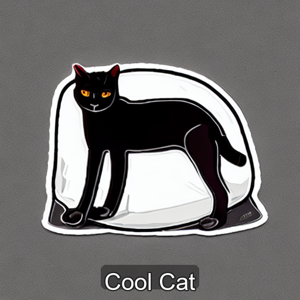


[flat] "Little Deer"


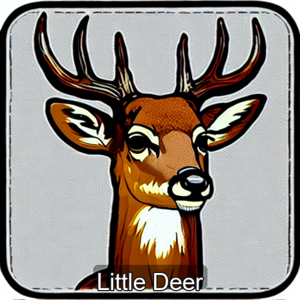


[flat] "Tabby Cat"


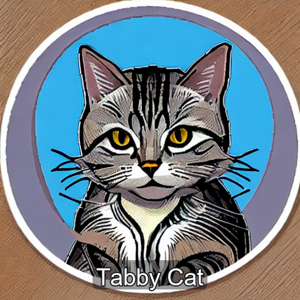


[flat] "Fluffy Dog"


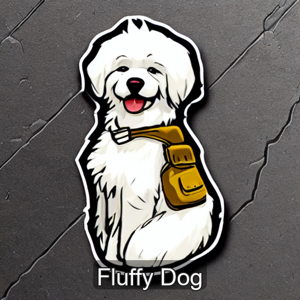


[flat] "Sweet Cow"


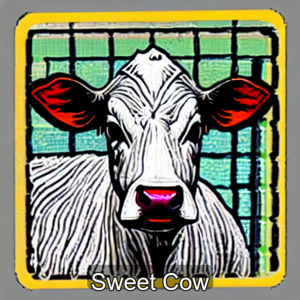


[flat] "Slow Turtle"


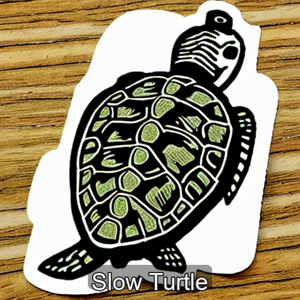

In [9]:
def show_results(results: list, max_show: int = 6):
    """Display a selection of processed sticker results."""
    if not results:
        print("No results to display.")
        print("Tip: place sticker images into input_stickers/<style>/ and re-run.")
        return

    shown = results[:max_show]
    print(f"Showing {len(shown)} of {len(results)} results:\n")

    for r in shown:
        out_path = r["output"]
        if os.path.exists(out_path):
            print(f'[{r["style"]}] "{r["caption"]}"')
            img = Image.open(out_path)
            display_img = img.copy()
            display_img.thumbnail((300, 300))
            display(display_img)
            print()


show_results(results)

## [Cell 17] 7. Summary

In [10]:
def print_summary(results: list):
    """Print a summary of the batch processing run."""
    if not results:
        print("No images were processed.\n")
        print("=== Quick Start ===")
        print("1. Copy generated sticker images into:")
        for style, dirs in STYLE_INPUT_MAP.items():
            print(f"   {dirs[0].resolve()}")
        print("2. (Optional) Edit text_captions.json to customize captions")
        print("3. Re-run this notebook from the top")
        return

    style_counts = {}
    for r in results:
        s = r["style"]
        style_counts[s] = style_counts.get(s, 0) + 1

    print("=== Processing Summary ===")
    print(f"  Total stickers processed: {len(results)}")
    for style, count in style_counts.items():
        print(f"    {style:12s}: {count} images")
    print(f"  Output directory: {OUTPUT_DIR.resolve()}")
    print(f"  Output format:    {OUTPUT_FORMAT}")
    print(f"  Output size:      {OUTPUT_SIZE}")
    print()
    print("All final stickers are ready for submission!")


print_summary(results)

=== Processing Summary ===
  Total stickers processed: 111
    flat        : 37 images
    cartoon     : 37 images
    watercolor  : 37 images
  Output directory: C:\Users\93480\Desktop\开学\学习\下学期\6209\大作业\stat-6209-topic-3-project\step5-textual-generate\output_final
  Output format:    PNG
  Output size:      (512, 512)

All final stickers are ready for submission!


---
*[Cell 19] End of notebook. STAT 6209 Topic 3 — Step 5: Optional Textual Generate*